In [ ]:
import numpy as np# type: ignore
import scipy as sp# type: ignore
import pandas as pd# type: ignore
import matplotlib.pyplot as plt# type: ignore
import sys
sys.path.append('/Users/leonardosantoro/Documents/GitHub/RiemannianEB/src')
from utils import *
from tqdm import tqdm

tau2 = 0.125
def sample_G(n_samples, tau2 = tau2): 
    circle = Hypersphere(1)
    mean1 = np.array([1./np.sqrt(2), 1./np.sqrt(2)])
    mean2 = -mean1
    classes = np.random.randint(0,2,n_samples).reshape(-1,1)
    samples1 = circle.random_riemannian_normal(mean1, 1./tau2, n_samples)
    samples2 = circle.random_riemannian_normal(mean2, 1./tau2, n_samples)
    return classes*samples1 + (1-classes)*samples2

plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})
# ------------------------------------------------------------------------------------------------------------
# ------------------------------------------------------------------------------------------------------------
# ------------------------------------------------------------------------------------------------------------
n = 1000
sigma2 = .2
M = 5
rho = 1e-12
NMC = 10

def MCrun(sample_G, n, sigma2, M , rho):
    circle = Hypersphere(1)
    Theta = sample_G(n)
    X = circle.random_riemannian_normal(Theta, 1./sigma2, n)
    delta = denoiser(circle, X, M, rho,  sigma2, X)
    delta_I = circle.intrinsic_to_extrinsic_coords(delta)
    X_I = circle.intrinsic_to_extrinsic_coords(X)
    Theta_I = circle.intrinsic_to_extrinsic_coords(Theta)
    loss_T = circle.metric.dist_broadcast(delta_I, Theta_I).ravel()**2      
    loss_N = circle.metric.dist_broadcast(X_I, Theta_I).ravel()**2
    return loss_T, loss_N

loss_T_all = np.zeros((NMC, n))
loss_N_all = np.zeros((NMC, n))
for imc in tqdm(range(NMC), total = NMC, desc = 'MC runs'):
    loss_T, loss_N = MCrun(sample_G, n, sigma2, M, rho)
    loss_T_all[imc,:] = loss_T.mean()
    loss_N_all[imc,:] = loss_N.mean()



# ----- visualization ------------------------------------------------------------------------------------------------------- 
import seaborn as sns
data_to_plot = pd.DataFrame({
    'Denoised (T)': (loss_T_all**.5).flatten(),
    'Naive': (loss_N_all**.5).flatten()})

fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(1, 3, 1, polar=True)

# Panel 0: hat_f -----------------------------------------------------------------------------------------------------------
f_scale = 0.3
res = 100
bottom = .5
incr = 20
angs = np.radians(np.arange(0, 360, incr))
angs_fill = np.append(angs, 2*np.pi)  # add 360 deg in radians
bottom_fill = np.append(bottom*np.ones_like(angs), bottom)
grid = np.asarray([np.cos(np.linspace(0, 2*np.pi, 100)),np.sin(np.linspace(0, 2*np.pi, 100))]).T

Theta = sample_G(1000)
grid_I, hat_f, hat_grad_f = density_estimate(Hypersphere(1), Theta, M,  grid)

hat_f_pos = np.maximum(hat_f, 0); norm_hat_f = hat_f_pos / np.max(hat_f_pos)
ax1.bar(grid_I, f_scale*hat_f_pos, width=2*np.pi/res, bottom=bottom, color=plt.colormaps['Reds'](norm_hat_f), alpha=0.8, align='edge')
ax1.set_title('PRIOR $g(\cdot )$')
ax1.plot(angs_fill, bottom_fill*np.ones_like(angs_fill), color='black', linewidth=1., zorder=5)
ax1.fill_between(angs_fill, np.zeros_like(angs_fill), bottom_fill, color='white', zorder=4)

# Central plot: Boxplot ------------------------------------------------------------------------------------------------------
ax2 = fig.add_subplot(1, 3, 2)
sns.boxplot(data=data_to_plot, ax=ax2)
ax2.set_ylabel('Loss')
ax2.set_title('MC Risk')
# Add text box with parameters ----------------------------------------------------------------------------------------------
textstr = '\n'.join((
    f'NMC = {NMC}',
    f'n = {n}',
    f'$\tau^2$ = {tau2}',
    f'$\sigma^2$ = {sigma2}',
    f'M = {M}',
    f'ρ = {rho:.0e}'))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(1.05, 0.5, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='center', bbox=props)

# Right plot: Quiver  ------------------------------------------------------------------------------------------------------
ax3 = fig.add_subplot(1, 3, 3)
X = Hypersphere(1).random_riemannian_normal(Theta, 1./sigma2, 1000)
grid_I, hat_f, hat_grad_f = density_estimate(Hypersphere(1), X, M,  grid)
hat_score = hat_grad_f / np.maximum(hat_f.ravel(), rho)
ax3.quiver( grid[:,0], grid[:,1], hat_score * grid[:,1], -hat_score * grid[:,0],
             alpha=0.7,
            #   color = 'g'
            color=plt.cm.Greens(np.abs(hat_score )),
            width=0.005, headwidth=15, headlength=4
)
ax3.set_title('Score Function')
ax3.axis('equal')
ax3.set_axis_off()


plt.tight_layout()
plt.show()
fig.savefig('out/S1.png', dpi=300)

MC runs: 100%|██████████| 10/10 [00:07<00:00,  1.28it/s]


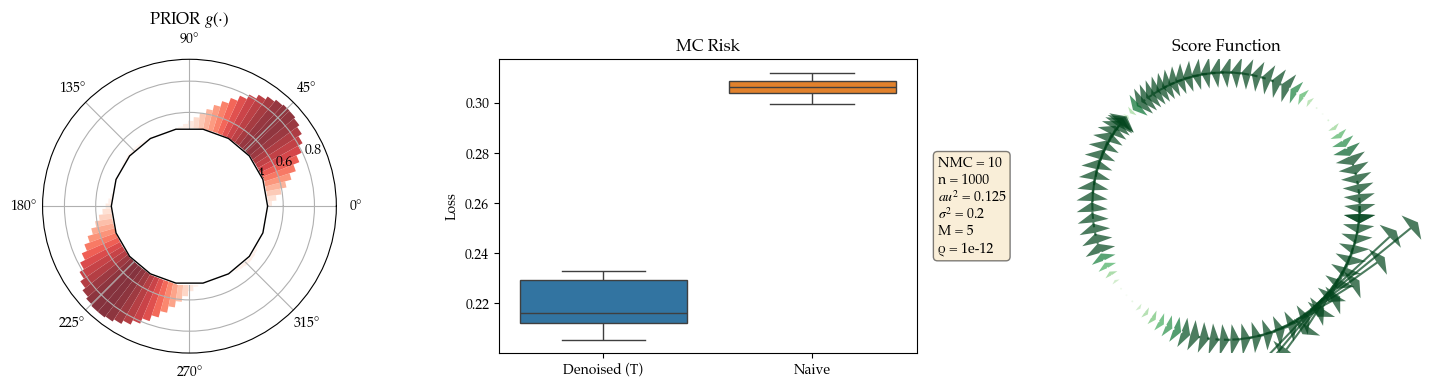

FileNotFoundError: [Errno 2] No such file or directory: '../out/S1.png'

In [ ]:

# ----- visualization ------------------------------------------------------------------------------------------------------- 
import seaborn as sns
data_to_plot = pd.DataFrame({
    'Denoised (T)': (loss_T_all**.5).flatten(),
    'Naive': (loss_N_all**.5).flatten()})

fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(1, 3, 1, polar=True)

# Panel 0: hat_f -----------------------------------------------------------------------------------------------------------
alpha = 0.8
f_scale = 0.3
res = 100
bottom = .5
incr = 20
angs = np.radians(np.arange(0, 360, incr))
angs_fill = np.append(angs, 2*np.pi)  # add 360 deg in radians
bottom_fill = np.append(bottom*np.ones_like(angs), bottom)
grid = np.asarray([np.cos(np.linspace(0, 2*np.pi, 100)),np.sin(np.linspace(0, 2*np.pi, 100))]).T

Theta = sample_G(1000)
grid_I, hat_f, hat_grad_f = density_estimate(Hypersphere(1), Theta, M,  grid)

hat_f_pos = np.maximum(hat_f, 0); norm_hat_f = hat_f_pos / np.max(hat_f_pos)
ax1.bar(grid_I, f_scale*hat_f_pos, width=2*np.pi/res, bottom=bottom, color=plt.colormaps['Reds'](norm_hat_f), alpha=alpha, align='edge')
ax1.set_title('PRIOR $g(\cdot )$')
ax1.plot(angs_fill, bottom_fill*np.ones_like(angs_fill), color='black', linewidth=1., zorder=5)
ax1.fill_between(angs_fill, np.zeros_like(angs_fill), bottom_fill, color='white', zorder=4)

# Central plot: Boxplot ------------------------------------------------------------------------------------------------------
ax2 = fig.add_subplot(1, 3, 2)
sns.boxplot(data=data_to_plot, ax=ax2)
ax2.set_ylabel('Loss')
ax2.set_title('MC Risk')
# Add text box with parameters ----------------------------------------------------------------------------------------------
textstr = '\n'.join((
    f'NMC = {NMC}',
    f'n = {n}',
    f'$\tau^2$ = {tau2}',
    f'$\sigma^2$ = {sigma2}',
    f'M = {M}',
    f'ρ = {rho:.0e}'))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(1.05, 0.5, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='center', bbox=props)

# Right plot: Quiver  ------------------------------------------------------------------------------------------------------
ax3 = fig.add_subplot(1, 3, 3)
X = Hypersphere(1).random_riemannian_normal(Theta, 1./sigma2, 1000)
grid_I, hat_f, hat_grad_f = density_estimate(Hypersphere(1), X, M,  grid)
hat_score = hat_grad_f / np.maximum(hat_f.ravel(), rho)
ax3.quiver( grid[:,0], grid[:,1], hat_score * grid[:,1], -hat_score * grid[:,0],
             alpha=0.7,
            #   color = 'g'
            color=plt.cm.Greens(np.abs(hat_score )),
            width=0.005, headwidth=15, headlength=4
)
ax3.set_title('Score Function')
ax3.axis('equal')
ax3.set_axis_off()


plt.tight_layout()
plt.show()
fig.savefig('out/S1.png', dpi=300)

In [165]:
np.linalg.norm(hat_score).ravel()

array([24.40055374])

In [167]:
hat_grad_f

array([ 0.79363095,  0.78995515,  0.77285481,  0.74501041,  0.7089201 ,
        0.66656207,  0.61914837,  0.56700027,  0.50956082,  0.44554406,
        0.3732042 ,  0.29069374,  0.196468  ,  0.08968737, -0.02943291,
       -0.15937126, -0.29718278, -0.4385394 , -0.57793304, -0.70903   ,
       -0.82514786, -0.91981159, -0.9873354 , -1.02337164, -1.02536934,
       -0.99289157, -0.92775351, -0.83395947, -0.71743694, -0.58558536,
       -0.44667675, -0.30916079, -0.18093798, -0.06866942,  0.0228098 ,
        0.09091528,  0.13553156,  0.15899863,  0.16586298,  0.16241215,
        0.15603264,  0.15444916,  0.16491524,  0.19343158,  0.24406691,
        0.31844813,  0.41547124,  0.53126508,  0.65941623,  0.79143941,
        0.91745452,  1.02701176,  1.10999183,  1.15750077,  1.16267825,
        1.12134595,  1.03243652,  0.89816306,  0.72391308,  0.51787506,
        0.29043044,  0.05336452, -0.18103397, -0.40090551, -0.59570319,
       -0.75695087, -0.87881215, -0.9584244 , -0.99597385, -0.99

In [ ]:
# c = np.abs(hat_score).ravel() / np.max(np.abs(hat_score))
# ax3.quiver(grid[:,0], grid[:,1],Vx, Vy, c,
#             scale=5, alpha=0.7, color=plt.cm.Greens(np.abs(hat_score).ravel() / np.max(np.abs(hat_score))))
# ax3.quiver(grid[:,0], grid[:,1], Vx, Vy,

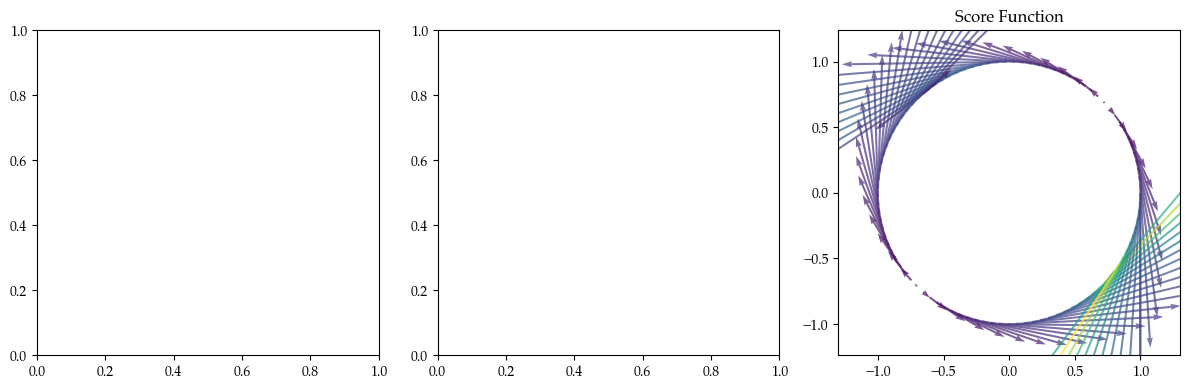

In [150]:
fig, (axl, axc, axr) = plt.subplots(1,3, figsize=(12,4))

# X = Hypersphere(1).random_riemannian_normal(Theta, 1./sigma2, 1000)
# grid = np.asarray([np.cos(np.linspace(0, 2*np.pi, 100)),np.sin(np.linspace(0, 2*np.pi, 100))]).T
# grid_I, hat_f, hat_grad_f = density_estimate(Hypersphere(1), X, M,  grid)
# hat_score = hat_grad_f / np.maximum(hat_f.ravel(), rho)


hat_score = (hat_grad_f / np.maximum(hat_f, rho))
axr.quiver(grid[:,0], grid[:,1],
            hat_score * grid[:,1], -hat_score * grid[:,0],
            scale=5, alpha=0.7, color=plt.cm.viridis(np.abs(hat_score).ravel() / np.max(np.abs(hat_score))))
axr.set_title('Score Function')
plt.axis('equal')
plt.tight_layout()
plt.show()